# Performance Analytics
## Mutual Fund Analytics Capstone Project
### Day 4: Performance Metrics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nav_df = pd.read_csv("../data/processed/nav_history_cleaned.csv")

In [3]:
plt.savefig("../dashboard/daily_return_distribution.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [4]:
nav_df = pd.read_csv("../data/processed/nav_history_cleaned.csv")

In [5]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [6]:
nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

In [7]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

In [8]:
nav_df.head(15)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [9]:
nav_df["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

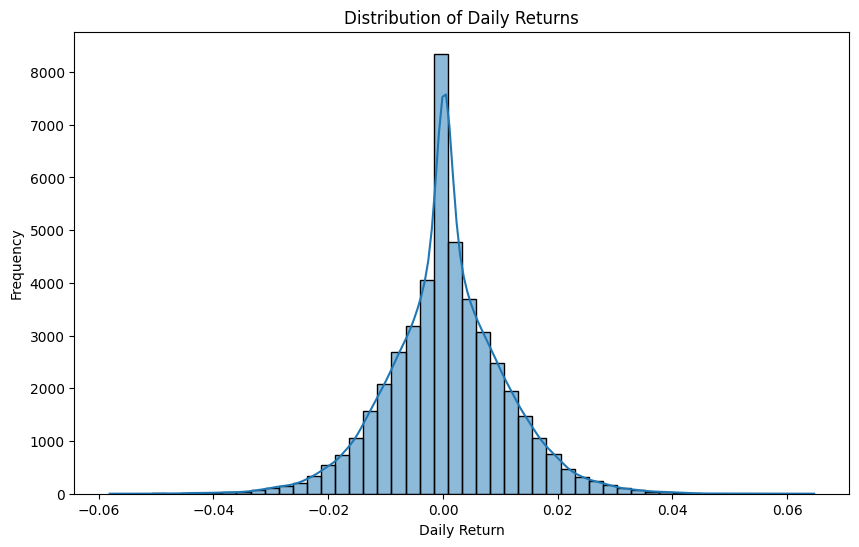

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_df["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.savefig("../dashboard/daily_return_distribution.png", dpi=300)

plt.show()

## Daily Return Analysis

The daily return distribution is centered close to zero, indicating that most daily NAV changes are relatively small. A small number of extreme positive and negative returns represent periods of higher market volatility.

In [11]:
plt.savefig("../dashboard/daily_return_distribution.png", dpi=300)

<Figure size 640x480 with 0 Axes>

task 2

In [12]:
import pandas as pd

nav_df = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])

In [13]:
nav_df = nav_df.sort_values(["amfi_code", "date"])

In [14]:
def calculate_cagr(df, years):
    
    results = []

    for code, group in df.groupby("amfi_code"):

        group = group.sort_values("date")

        end_date = group["date"].max()

        start_date = end_date - pd.DateOffset(years=years)

        start_rows = group[group["date"] >= start_date]

        if len(start_rows) == 0:
            continue

        start_nav = start_rows.iloc[0]["nav"]
        end_nav = group.iloc[-1]["nav"]

        cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

        results.append([code, round(cagr, 2)])

    return pd.DataFrame(results, columns=["amfi_code", f"CAGR_{years}Y"])

In [15]:
cagr_1 = calculate_cagr(nav_df, 1)

cagr_3 = calculate_cagr(nav_df, 3)

cagr_5 = calculate_cagr(nav_df, 5)

In [16]:
cagr_table = cagr_1.merge(cagr_3, on="amfi_code")

cagr_table = cagr_table.merge(cagr_5, on="amfi_code")

In [17]:
fund_df = pd.read_csv("../data/raw/01_fund_master.csv")

cagr_table = cagr_table.merge(
    fund_df[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

cagr_table = cagr_table[
    ["amfi_code", "scheme_name", "CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]
]

In [18]:
cagr_table.head(10)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.22,1.29,2.32
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.70,3.92,3.91
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,26.07
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,20.44
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.99,-4.15,6.95
5,101208,ABSL Liquid Fund - Regular - Growth,7.24,6.32,5.71
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,20.21,19.67,15.88
7,102886,UTI Mid Cap Fund - Regular - Growth,-16.80,-0.77,1.03
8,102887,UTI Flexi Cap Fund - Regular - Growth,13.58,25.56,14.68
9,118632,Nippon India Large Cap Fund - Regular - Growth,33.98,22.65,20.88


In [19]:
cagr_table.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

In [20]:
cagr_table.sort_values(
    "CAGR_5Y",
    ascending=False
).head(10)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
25,120505,ICICI Pru Midcap Fund - Regular - Growth,29.60,31.78,28.38
21,119598,SBI Small Cap Fund - Regular Plan - Growth,82.78,26.67,28.03
39,149324,DSP Small Cap Fund - Regular - Growth,65.14,27.00,27.92
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,39.75,29.18,27.63
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.36,34.00,26.80
30,120843,Kotak Flexicap Fund - Regular - Growth,26.66,29.58,26.74
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,26.07
38,149323,DSP Midcap Fund - Regular - Growth,21.48,26.87,25.61
16,119094,Axis Midcap Fund - Regular - Growth,22.26,35.11,24.45
19,119551,SBI Bluechip Fund - Regular Plan - Growth,60.44,30.46,22.38


## CAGR Analysis

The CAGR comparison highlights the long-term annualized growth of each mutual fund scheme over 1-year, 3-year, and 5-year periods. Funds with consistently higher CAGR values demonstrate superior long-term performance and effective portfolio management.

In [22]:
import pandas as pd
import numpy as np

In [23]:
nav_df = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(["amfi_code","date"])

In [24]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

In [25]:
risk_free_rate = 0.065

daily_rf = risk_free_rate / 252

In [26]:
sharpe_list = []

for code, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    avg_return = returns.mean()

    std_return = returns.std()

    sharpe = ((avg_return - daily_rf) / std_return) * np.sqrt(252)

    sharpe_list.append([code, sharpe])

In [27]:
sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "Sharpe_Ratio"
    ]
)

In [28]:
fund_df = pd.read_csv("../data/raw/01_fund_master.csv")

sharpe_df = sharpe_df.merge(

    fund_df[["amfi_code","scheme_name"]],

    on="amfi_code"

)

In [29]:
sharpe_df = sharpe_df.sort_values(

    "Sharpe_Ratio",

    ascending=False

)

sharpe_df.reset_index(drop=True,inplace=True)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio,scheme_name
0,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
1,120843,1.306744,Kotak Flexicap Fund - Regular - Growth
2,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
3,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth
4,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth
5,149323,1.132122,DSP Midcap Fund - Regular - Growth
6,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
7,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth
8,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
9,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [30]:
sharpe_df.to_csv(

    "../reports/sharpe_ratio.csv",

    index=False

)

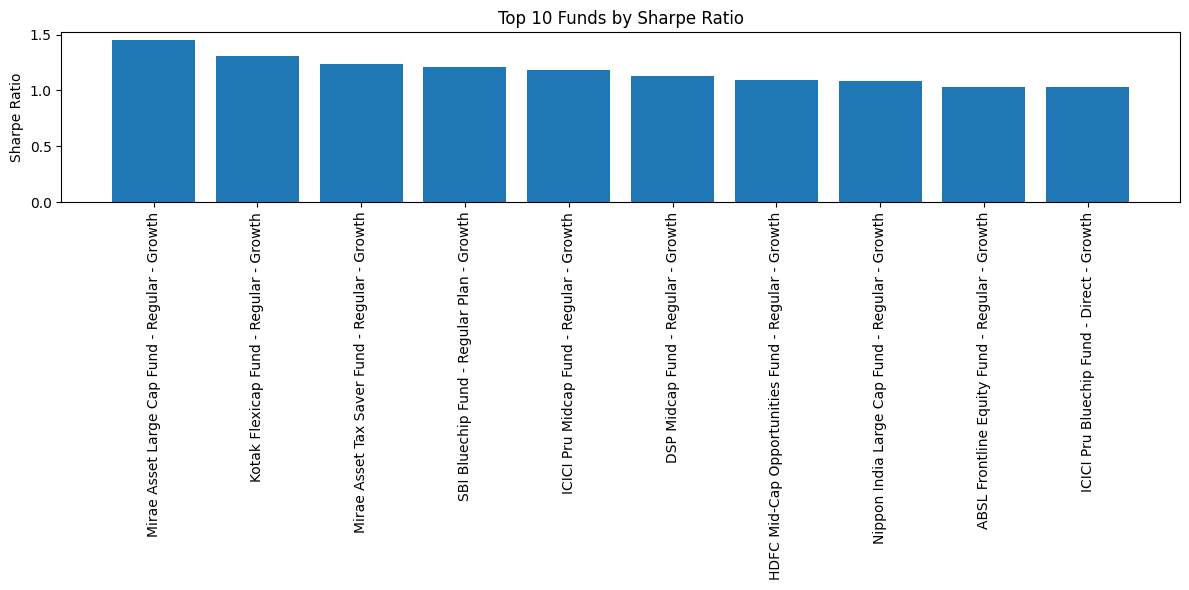

In [31]:
import matplotlib.pyplot as plt

top10 = sharpe_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(

    top10["scheme_name"],

    top10["Sharpe_Ratio"]

)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.ylabel("Sharpe Ratio")

plt.tight_layout()

plt.savefig(

    "../dashboard/sharpe_ratio.png",

    dpi=300

)

plt.show()

## Sharpe Ratio Analysis

The Sharpe Ratio measures the return generated per unit of total risk. Funds with higher Sharpe Ratios have delivered better risk-adjusted performance, indicating efficient portfolio management and superior returns relative to their volatility.

task 4
Task 4: Sortino Ratio


In [32]:
import pandas as pd
import numpy as np

nav_df = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(["amfi_code", "date"])

In [33]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

In [34]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

In [35]:
sortino_list = []

for code, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    avg_return = returns.mean()

    # Only negative returns
    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = ((avg_return - daily_rf) / downside_std) * np.sqrt(252)

    sortino_list.append([code, sortino])

In [36]:
sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "Sortino_Ratio"]
)

In [37]:
fund_df = pd.read_csv("../data/raw/01_fund_master.csv")

sortino_df = sortino_df.merge(
    fund_df[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

In [38]:
sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_df.reset_index(drop=True, inplace=True)

sortino_df.head(10)

,amfi_code,Sortino_Ratio,scheme_name
0,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
1,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
2,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
3,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
4,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth
5,149323,1.875101,DSP Midcap Fund - Regular - Growth
6,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth
7,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
8,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
9,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth


In [39]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

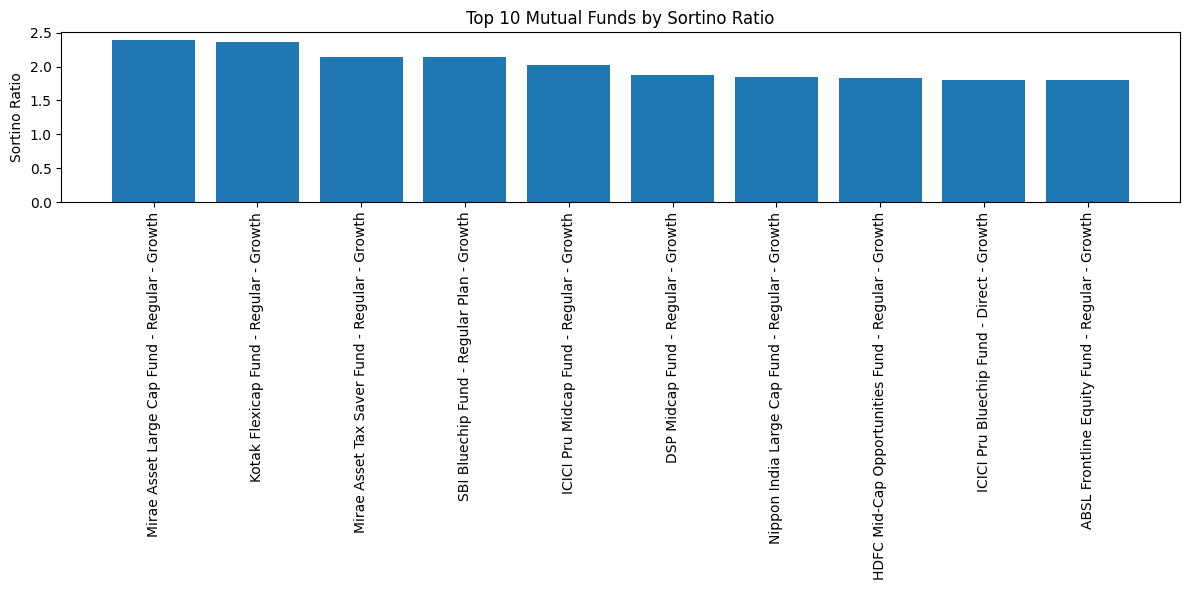

In [40]:
import matplotlib.pyplot as plt

top10 = sortino_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["scheme_name"],
    top10["Sortino_Ratio"]
)

plt.xticks(rotation=90)

plt.ylabel("Sortino Ratio")

plt.title("Top 10 Mutual Funds by Sortino Ratio")

plt.tight_layout()

plt.savefig(
    "../dashboard/sortino_ratio.png",
    dpi=300
)

plt.show()

## Sortino Ratio Analysis

The Sortino Ratio evaluates the return earned per unit of downside risk by considering only negative return volatility. Funds with higher Sortino Ratios have generated stronger returns while minimizing downside fluctuations, making them attractive for long-term investors seeking better downside protection.

task 5
Alpha & Beta

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [109]:
nav_df = pd.read_csv("../data/processed/nav_history_cleaned.csv")

benchmark_df = pd.read_csv("../data/raw/10_benchmark_indices.csv")

scheme_df = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

In [110]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

In [113]:
benchmark = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

benchmark = benchmark.sort_values("date")

In [112]:
benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

benchmark.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [114]:
nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

nav_df["fund_return"] = (
    nav_df.groupby("amfi_code")["nav"].pct_change()
)

nav_df.head()


,amfi_code,date,nav,fund_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [115]:
nav_df = nav_df.merge(
    scheme_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav_df.head()

,amfi_code,date,nav,fund_return,scheme_name
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth


In [116]:
nav_df = nav_df.merge(
    scheme_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav_df.head()

,amfi_code,date,nav,fund_return,scheme_name_x,scheme_name_y
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth


In [117]:
merged = pd.merge(
    nav_df,
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print(merged.shape)

merged.head()

KeyError: "['benchmark_return'] not in index"

In [118]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='object')


In [119]:
benchmark = benchmark.sort_values("date").copy()

benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

benchmark.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [120]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='object')


In [121]:
merged = pd.merge(
    nav_df,
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print(merged.shape)
merged.head()

(46000, 7)


,amfi_code,date,nav,fund_return,scheme_name_x,scheme_name_y,benchmark_return
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,NaN
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,-0.013540
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,0.004003
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,0.006150


In [122]:
merged = pd.merge(
    nav_df,
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print(merged.shape)

merged.head()

(46000, 7)


,amfi_code,date,nav,fund_return,scheme_name_x,scheme_name_y,benchmark_return
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,NaN
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,-0.013540
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,0.004003
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,0.006150


In [128]:
results = []

for amfi_code, group in merged.groupby("amfi_code"):

    group = group.dropna()

    if len(group) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        group["benchmark_return"],
        group["fund_return"]
    )

    alpha = intercept * 252
    beta = slope

    scheme_name = group["scheme_name_x"].iloc[0]

    results.append([
        amfi_code,
        alpha,
        beta,
        scheme_name
    ])

alpha_beta = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "Alpha",
        "Beta",
        "scheme_name"
    ]
)

alpha_beta.head()

,amfi_code,Alpha,Beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [124]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='object')


In [125]:
benchmark = benchmark.sort_values("date").copy()

benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

benchmark.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [126]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='object')


In [127]:
merged = pd.merge(
    nav_df,
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print(merged.shape)
merged.head()

(46000, 7)


,amfi_code,date,nav,fund_return,scheme_name_x,scheme_name_y,benchmark_return
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,NaN
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,-0.013540
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,0.004003
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,0.006150


In [129]:
print(alpha_beta.shape)
alpha_beta.head()

(40, 4)


,amfi_code,Alpha,Beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [130]:
print(alpha_beta.shape)
alpha_beta.head()

(40, 4)


,amfi_code,Alpha,Beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [131]:
import os

print(os.path.exists("../reports/alpha_beta.csv"))

True


In [132]:
import os

print(os.path.exists("../dashboard/alpha_beta.png"))

False


In [133]:
benchmark.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [134]:
print(merged.shape)
merged.head()

(46000, 7)


,amfi_code,date,nav,fund_return,scheme_name_x,scheme_name_y,benchmark_return
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,NaN
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,-0.013540
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,0.004003
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,0.006150


In [135]:
alpha_beta.describe()

,amfi_code,Alpha,Beta
count,40.000000,40.000000,40.000000
mean,120247.000000,0.159085,-0.001958
std,14534.998667,0.087528,0.035194
min,100016.000000,0.028969,-0.066951
25%,118632.750000,0.068612,-0.023937
50%,119551.500000,0.162326,-0.000067
75%,120842.250000,0.221723,0.017026
max,149324.000000,0.303370,0.103497


In [136]:
import os

print("Alpha Beta Shape:", alpha_beta.shape)

print("\nCSV Exists:", os.path.exists("../reports/alpha_beta.csv"))

print("Graph Exists:", os.path.exists("../dashboard/alpha_beta.png"))

print("\nMerged Shape:", merged.shape)

print("\nAlpha Beta Columns:")
print(alpha_beta.columns)

print("\nFirst Five Rows:")
print(alpha_beta.head())

Alpha Beta Shape: (40, 4)

CSV Exists: True
Graph Exists: False

Merged Shape: (46000, 7)

Alpha Beta Columns:
Index(['amfi_code', 'Alpha', 'Beta', 'scheme_name'], dtype='object')

First Five Rows:
   amfi_code     Alpha      Beta  \
0     100016  0.037476 -0.058268   
1     100025  0.042818  0.001158   
2     100033  0.271954  0.005104   
3     101206  0.213998  0.021086   
4     101207  0.108971 -0.065289   

                                         scheme_name  
0          HDFC Top 100 Fund - Regular Plan - Growth  
1       HDFC Short Term Debt Fund - Regular - Growth  
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  
3      ABSL Frontline Equity Fund - Regular - Growth  
4             ABSL Small Cap Fund - Regular - Growth  


In [137]:
import os

os.makedirs("../dashboard", exist_ok=True)

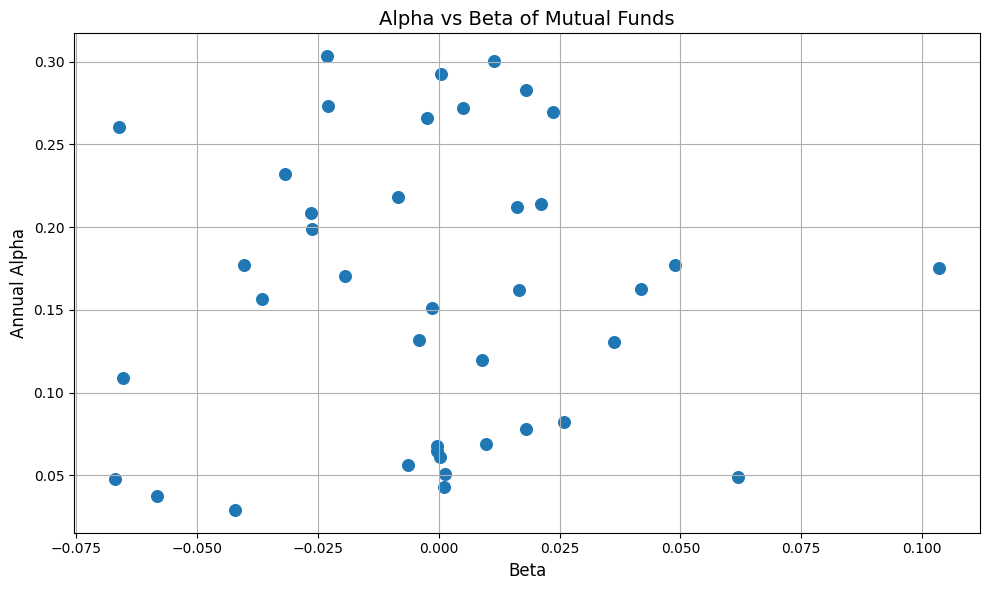

In [138]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    alpha_beta["Beta"],
    alpha_beta["Alpha"],
    s=70
)

plt.xlabel("Beta", fontsize=12)
plt.ylabel("Annual Alpha", fontsize=12)
plt.title("Alpha vs Beta of Mutual Funds", fontsize=14)

plt.grid(True)

plt.tight_layout()

plt.savefig("../dashboard/alpha_beta.png", dpi=300)

plt.show()

In [139]:
import os

print(os.path.exists("../dashboard/alpha_beta.png"))

True


TASK 6 Maximum Drawdown (MDD)

In [61]:
import pandas as pd
import numpy as np

nav_df = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(["amfi_code", "date"])

In [62]:
nav_df["running_max"] = (
    nav_df.groupby("amfi_code")["nav"]
          .cummax()
)

In [63]:
nav_df["drawdown"] = (
    nav_df["nav"] / nav_df["running_max"]
) - 1

In [64]:
mdd_df = (
    nav_df.groupby("amfi_code")["drawdown"]
          .min()
          .reset_index()
)

mdd_df.rename(
    columns={"drawdown": "Maximum_Drawdown"},
    inplace=True
)

In [65]:
fund_df = pd.read_csv("../data/raw/01_fund_master.csv")

mdd_df = mdd_df.merge(
    fund_df[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

In [66]:
mdd_df["Maximum_Drawdown"] = (
    mdd_df["Maximum_Drawdown"] * 100
).round(2)


In [67]:
mdd_df = mdd_df.sort_values(
    "Maximum_Drawdown",
    ascending=False
)

mdd_df.head(10)

,amfi_code,Maximum_Drawdown,scheme_name
27,120507,-0.10,ICICI Pru Liquid Fund - Regular - Growth
31,120844,-0.12,Kotak Liquid Fund - Regular - Growth
5,101208,-0.16,ABSL Liquid Fund - Regular - Growth
1,100025,-4.31,HDFC Short Term Debt Fund - Regular - Growth
18,119120,-4.33,SBI Magnum Gilt Fund - Regular Plan - Growth
13,118636,-8.32,Nippon India Gilt Securities Fund - Regular - ...
6,102885,-10.86,UTI Nifty 50 Index Fund - Regular - Growth
34,148567,-11.27,Mirae Asset Large Cap Fund - Regular - Growth
3,101206,-11.29,ABSL Frontline Equity Fund - Regular - Growth
12,118635,-11.65,Nippon India ETF Nifty 50 BeES


In [68]:
worst_dates = (
    nav_df.loc[
        nav_df.groupby("amfi_code")["drawdown"].idxmin(),
        ["amfi_code", "date", "drawdown"]
    ]
)

worst_dates.rename(
    columns={
        "date": "Worst_Drawdown_Date",
        "drawdown": "Drawdown"
    },
    inplace=True
)

worst_dates["Drawdown"] = (
    worst_dates["Drawdown"] * 100
).round(2)

In [69]:
mdd_df = mdd_df.merge(
    worst_dates[
        ["amfi_code", "Worst_Drawdown_Date"]
    ],
    on="amfi_code"
)

In [70]:
mdd_df.head(10)

,amfi_code,Maximum_Drawdown,scheme_name,Worst_Drawdown_Date
0,120507,-0.10,ICICI Pru Liquid Fund - Regular - Growth,2025-10-20
1,120844,-0.12,Kotak Liquid Fund - Regular - Growth,2024-04-30
2,101208,-0.16,ABSL Liquid Fund - Regular - Growth,2023-09-12
3,100025,-4.31,HDFC Short Term Debt Fund - Regular - Growth,2023-07-28
4,119120,-4.33,SBI Magnum Gilt Fund - Regular Plan - Growth,2025-04-01
5,118636,-8.32,Nippon India Gilt Securities Fund - Regular - ...,2024-02-09
6,102885,-10.86,UTI Nifty 50 Index Fund - Regular - Growth,2022-03-29
7,148567,-11.27,Mirae Asset Large Cap Fund - Regular - Growth,2023-10-20
8,101206,-11.29,ABSL Frontline Equity Fund - Regular - Growth,2023-07-05
9,118635,-11.65,Nippon India ETF Nifty 50 BeES,2022-06-09


In [71]:
mdd_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

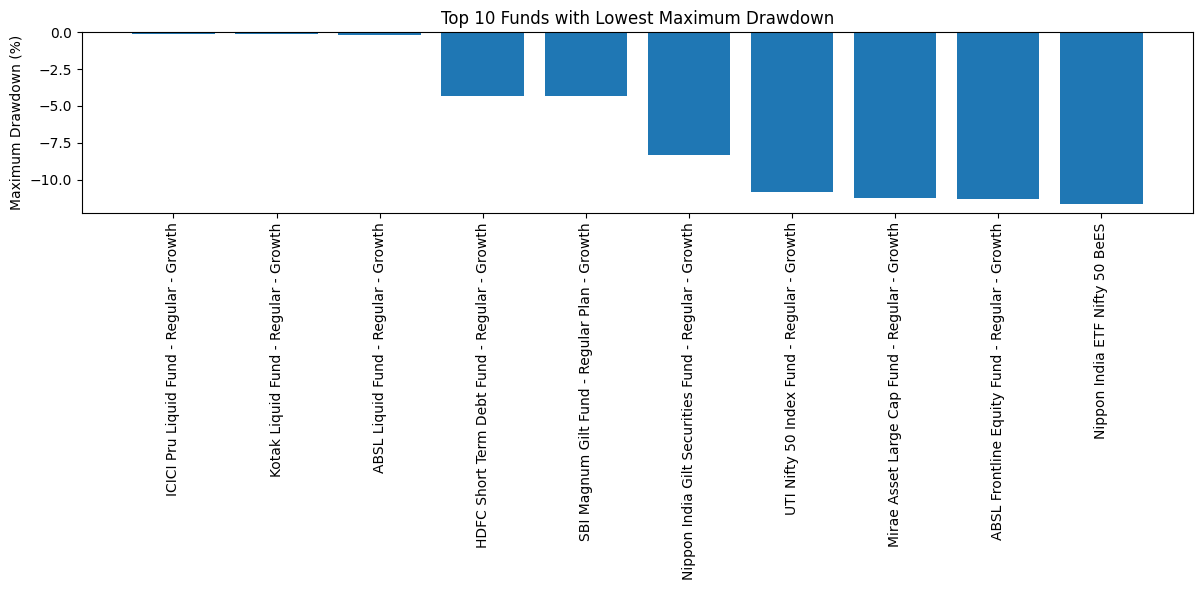

In [72]:
import matplotlib.pyplot as plt

top10 = mdd_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["scheme_name"],
    top10["Maximum_Drawdown"]
)

plt.xticks(rotation=90)

plt.ylabel("Maximum Drawdown (%)")

plt.title("Top 10 Funds with Lowest Maximum Drawdown")

plt.tight_layout()

plt.savefig(
    "../dashboard/maximum_drawdown.png",
    dpi=300
)

plt.show()

In [140]:
max_drawdown_df.to_csv("../reports/max_drawdown.csv", index=False)

NameError: name 'max_drawdown_df' is not defined

In [141]:
%who

alpha	 alpha_beta	 amfi_code	 avg_return	 benchmark	 benchmark_df	 beta	 cagr_1	 cagr_3	 
cagr_5	 cagr_table	 calculate_cagr	 code	 daily_rf	 downside_returns	 downside_std	 fund_df	 group	 
intercept	 linregress	 max_rank	 mdd	 mdd_df	 merged	 nav_df	 np	 os	 
p_value	 pd	 performance	 plt	 r_value	 results	 returns	 risk_free_rate	 scheme_df	 
scheme_name	 scorecard	 sharpe	 sharpe_df	 sharpe_list	 slope	 sns	 sortino	 sortino_df	 
sortino_list	 std_err	 std_return	 temp1	 temp2	 temp3	 top10	 worst_dates	 


In [142]:
mdd_df.head()

,amfi_code,Maximum_Drawdown,scheme_name,Worst_Drawdown_Date
0,120507,-0.10,ICICI Pru Liquid Fund - Regular - Growth,2025-10-20
1,120844,-0.12,Kotak Liquid Fund - Regular - Growth,2024-04-30
2,101208,-0.16,ABSL Liquid Fund - Regular - Growth,2023-09-12
3,100025,-4.31,HDFC Short Term Debt Fund - Regular - Growth,2023-07-28
4,119120,-4.33,SBI Magnum Gilt Fund - Regular Plan - Growth,2025-04-01


In [143]:
mdd_df.shape

(40, 4)

In [144]:
mdd_df.to_csv("../reports/max_drawdown.csv", index=False)

print("Saved successfully!")

Saved successfully!


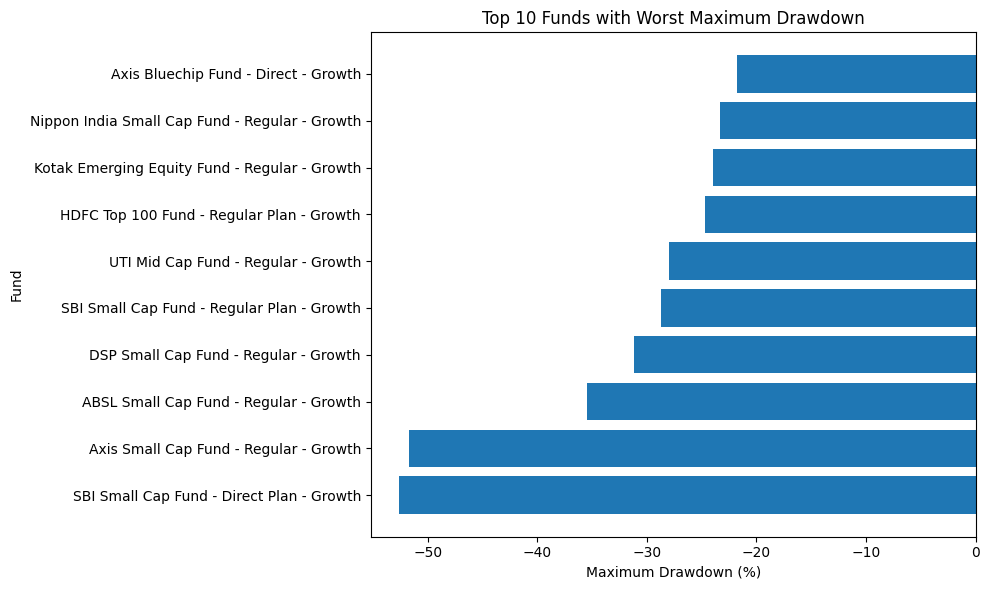

In [145]:
import matplotlib.pyplot as plt

top10 = mdd_df.sort_values("Maximum_Drawdown").head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["scheme_name"],
    top10["Maximum_Drawdown"]
)

plt.xlabel("Maximum Drawdown (%)")
plt.ylabel("Fund")
plt.title("Top 10 Funds with Worst Maximum Drawdown")

plt.tight_layout()

plt.savefig("../dashboard/max_drawdown.png", dpi=300)

plt.show()

In [146]:
import os

print(os.path.exists("../reports/max_drawdown.csv"))
print(os.path.exists("../dashboard/max_drawdown.png"))

True
True


## Maximum Drawdown Analysis

Maximum Drawdown measures the largest decline in a fund's NAV from its historical peak before recovering. Funds with smaller drawdowns demonstrated greater resilience during market downturns and experienced lower downside risk, making them more suitable for risk-conscious investors.

TASK 7  Fund Scorecard (0–100)

In [147]:
performance = scheme_df[[
    "amfi_code",
    "scheme_name",
    "return_3yr_pct",
    "expense_ratio_pct"
]]

scorecard = performance.merge(
    sharpe_df[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "Alpha"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    mdd_df[["amfi_code", "Maximum_Drawdown"]],
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-15.01
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-11.80
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-28.71
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-52.57
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-4.33


In [148]:
print(scorecard.isnull().sum())

amfi_code            0
scheme_name          0
return_3yr_pct       0
expense_ratio_pct    0
Sharpe_Ratio         0
Alpha                0
Maximum_Drawdown     0
dtype: int64


In [149]:
scorecard["Return_Rank"] = scorecard["return_3yr_pct"].rank(ascending=False)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["Drawdown_Rank"] = scorecard["Maximum_Drawdown"].rank(ascending=True)

In [150]:
max_rank = scorecard["Return_Rank"].max()

scorecard["Return_Score"] = (max_rank - scorecard["Return_Rank"] + 1) / max_rank * 100

scorecard["Sharpe_Score"] = (max_rank - scorecard["Sharpe_Rank"] + 1) / max_rank * 100

scorecard["Alpha_Score"] = (max_rank - scorecard["Alpha_Rank"] + 1) / max_rank * 100

scorecard["Expense_Score"] = (max_rank - scorecard["Expense_Rank"] + 1) / max_rank * 100

scorecard["Drawdown_Score"] = (max_rank - scorecard["Drawdown_Rank"] + 1) / max_rank * 100

In [151]:
scorecard["Fund_Score"] = (

      0.30 * scorecard["Return_Score"]

    + 0.25 * scorecard["Sharpe_Score"]

    + 0.20 * scorecard["Alpha_Score"]

    + 0.15 * scorecard["Expense_Score"]

    + 0.10 * scorecard["Drawdown_Score"]

)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-15.01,26.0,4.0,10.0,30.5,24.0,37.5,92.5,77.5,26.25,42.5,58.0625
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-11.80,34.0,12.0,15.0,4.0,30.0,17.5,72.5,65.0,92.50,27.5,53.0000
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-28.71,1.0,14.0,1.0,21.0,5.0,100.0,67.5,100.0,50.00,90.0,83.3750
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-52.57,2.0,32.0,36.0,5.5,1.0,97.5,22.5,12.5,88.75,100.0,60.6875
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-4.33,38.0,37.0,34.0,9.0,36.0,7.5,10.0,17.5,80.00,12.5,21.5000


In [152]:
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-28.71,1.0,14.0,1.0,21.0,5.0,100.0,67.5,100.0,50.00,90.0,83.3750
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,-18.19,8.0,5.0,3.0,15.0,16.0,82.5,90.0,95.0,65.00,62.5,82.2500
39,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.949796,0.300579,-31.17,6.0,13.0,2.0,26.5,4.0,87.5,70.0,97.5,36.25,92.5,77.9375
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,-16.22,10.0,7.0,6.0,17.0,21.0,77.5,85.0,87.5,60.00,50.0,76.0000
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-12.97,11.0,2.0,5.0,22.0,28.0,75.0,97.5,90.0,47.50,32.5,75.2500
26,119094,Axis Midcap Fund - Regular - Growth,15.18,1.38,0.998231,0.260767,-20.96,15.0,11.0,9.0,17.0,13.0,65.0,75.0,80.0,60.00,70.0,70.2500
38,149323,DSP Midcap Fund - Regular - Growth,17.16,1.61,1.132122,0.265986,-17.25,9.0,6.0,8.0,38.0,19.0,80.0,87.5,82.5,7.50,55.0,69.0000
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448291,0.269838,-11.27,17.0,1.0,7.0,23.0,33.0,60.0,100.0,85.0,45.00,20.0,68.7500
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,1.026524,0.211948,-12.59,20.0,10.0,13.0,12.0,29.0,52.5,77.5,70.0,72.50,30.0,63.0000
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.60,1.234930,0.282704,-16.40,23.0,3.0,4.0,36.5,20.0,45.0,95.0,92.5,11.25,52.5,62.6875


In [153]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully!")

Fund Scorecard saved successfully!


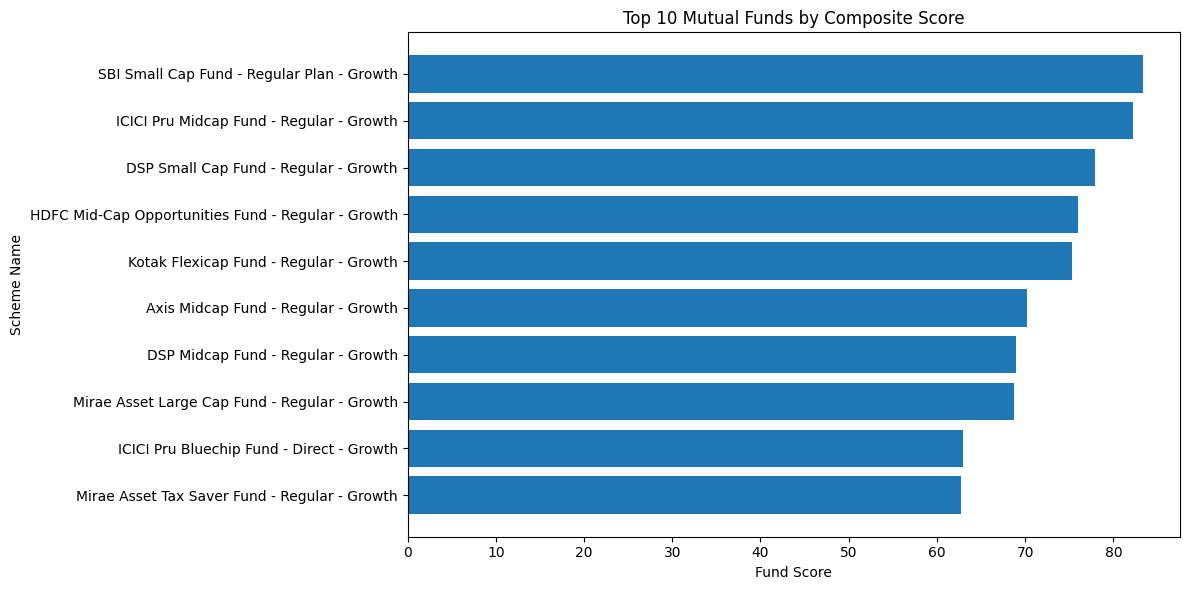

In [154]:
import matplotlib.pyplot as plt

top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["Fund_Score"]
)

plt.xlabel("Fund Score")
plt.ylabel("Scheme Name")
plt.title("Top 10 Mutual Funds by Composite Score")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../dashboard/fund_scorecard.png",
    dpi=300
)

plt.show()

In [155]:
import os

print(os.path.exists("../reports/fund_scorecard.csv"))
print(os.path.exists("../dashboard/fund_scorecard.png"))

True
True


task 8 BENCHMARK COMPARISION

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [157]:
top5 = scorecard.head(5)

top5_codes = top5["amfi_code"].tolist()

top5

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-28.71,1.0,14.0,1.0,21.0,5.0,100.0,67.5,100.0,50.00,90.0,83.3750
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,-18.19,8.0,5.0,3.0,15.0,16.0,82.5,90.0,95.0,65.00,62.5,82.2500
39,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.949796,0.300579,-31.17,6.0,13.0,2.0,26.5,4.0,87.5,70.0,97.5,36.25,92.5,77.9375
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,-16.22,10.0,7.0,6.0,17.0,21.0,77.5,85.0,87.5,60.00,50.0,76.0000
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-12.97,11.0,2.0,5.0,22.0,28.0,75.0,97.5,90.0,47.50,32.5,75.2500


In [158]:
top5_nav = nav_df[
    nav_df["amfi_code"].isin(top5_codes)
].copy()

top5_nav.head()

,amfi_code,date,nav,fund_return,scheme_name_x,scheme_name_y
2300,100033,2022-01-03,107.3758,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2301,100033,2022-01-04,105.9447,-0.013328,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2302,100033,2022-01-05,105.4800,-0.004386,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2303,100033,2022-01-06,104.9350,-0.005167,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2304,100033,2022-01-07,104.3318,-0.005748,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [159]:
benchmark = benchmark_df[
    benchmark_df["index_name"].isin(["NIFTY50","NIFTY100"])
].copy()

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [160]:
top5_nav["Normalized_NAV"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: x/x.iloc[0]*100)
)

benchmark["Normalized_Index"] = (
    benchmark.groupby("index_name")["close_value"]
    .transform(lambda x: x/x.iloc[0]*100)
)

In [161]:
plt.figure(figsize=(14,7))

for code in top5_codes:

    temp = top5_nav[
        top5_nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["Normalized_NAV"],
        label=temp["scheme_name"].iloc[0]
    )

for index in benchmark["index_name"].unique():

    temp = benchmark[
        benchmark["index_name"] == index
    ]

    plt.plot(
        temp["date"],
        temp["Normalized_Index"],
        linestyle="--",
        linewidth=3,
        label=index
    )

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")

plt.xlabel("Date")

plt.ylabel("Normalized Value (Base = 100)")

plt.legend(fontsize=8)

plt.grid(True)

plt.tight_layout()

plt.savefig("../dashboard/benchmark_comparison.png",dpi=300)

plt.show()

KeyError: 'scheme_name'

<Figure size 1400x700 with 0 Axes>

In [162]:
print(top5_nav.columns)

Index(['amfi_code', 'date', 'nav', 'fund_return', 'scheme_name_x',
       'scheme_name_y', 'Normalized_NAV'],
      dtype='object')


In [163]:
print(nav_df.columns)


Index(['amfi_code', 'date', 'nav', 'fund_return', 'scheme_name_x',
       'scheme_name_y'],
      dtype='object')


In [164]:
top5_nav = nav_df.merge(
    scheme_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top5_nav = top5_nav[
    top5_nav["amfi_code"].isin(top5_codes)
].copy()

In [175]:
# Normalize each fund's NAV to start at 100
top5_nav["Normalized_NAV"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

# Normalize benchmark indices to start at 100
benchmark["Normalized_Index"] = (
    benchmark.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

print(top5_nav.columns)
print(benchmark.columns)

Index(['amfi_code', 'date', 'nav', 'fund_return', 'scheme_name_x',
       'scheme_name_y', 'scheme_name', 'Normalized_NAV'],
      dtype='object')
Index(['date', 'index_name', 'close_value', 'Normalized_Index'], dtype='object')


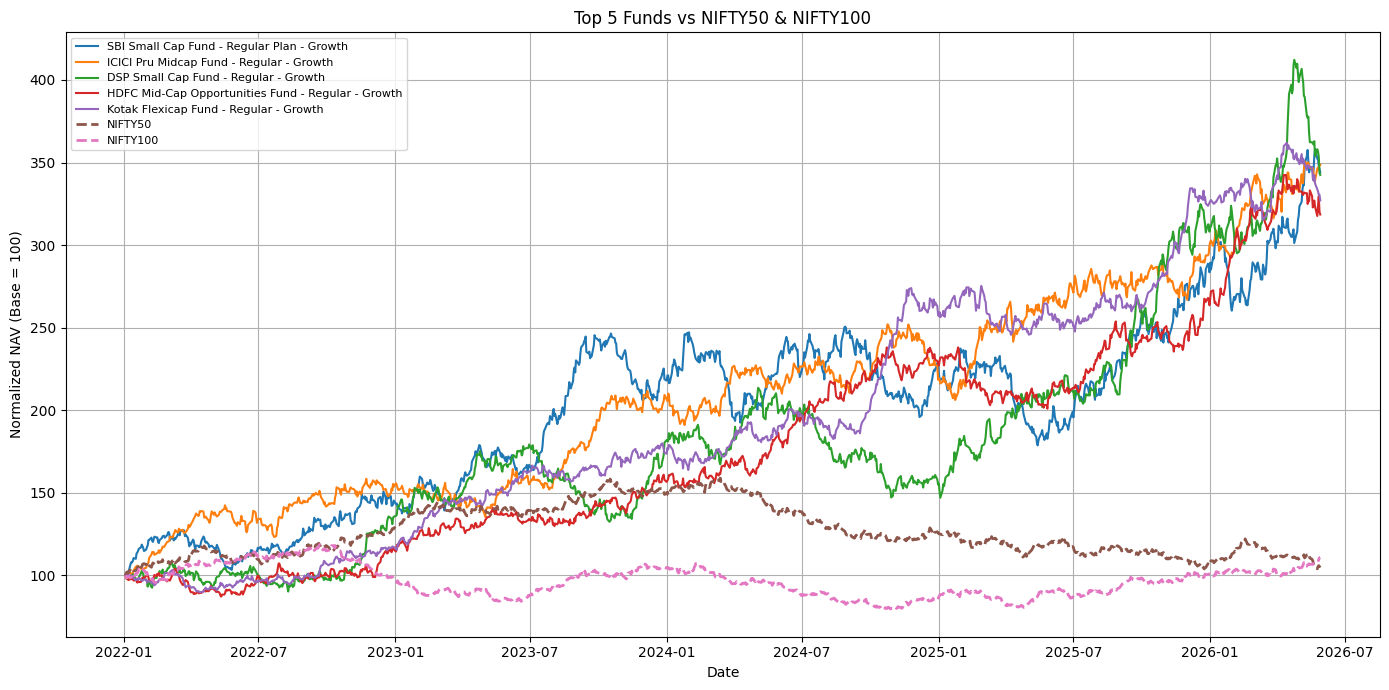

In [176]:
plt.figure(figsize=(14,7))

for code in top5_codes:

    temp = top5_nav[
        top5_nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["Normalized_NAV"],
        label=temp["scheme_name_x"].iloc[0]   # <-- Changed here
    )

for index in benchmark["index_name"].unique():

    temp = benchmark[
        benchmark["index_name"] == index
    ]

    plt.plot(
        temp["date"],
        temp["Normalized_Index"],
        linestyle="--",
        linewidth=2,
        label=index
    )

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")
plt.xlabel("Date")
plt.ylabel("Normalized NAV (Base = 100)")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()

plt.savefig("../dashboard/benchmark_comparison.png", dpi=300)

plt.show()

In [174]:
print(top5_nav.columns)

Index(['amfi_code', 'date', 'nav', 'fund_return', 'scheme_name_x',
       'scheme_name_y', 'scheme_name'],
      dtype='object')


In [166]:
print(top5_nav.columns)

Index(['amfi_code', 'date', 'nav', 'fund_return', 'scheme_name_x',
       'scheme_name_y', 'scheme_name'],
      dtype='object')


In [167]:
top5_nav.head()

,amfi_code,date,nav,fund_return,scheme_name_x,scheme_name_y,scheme_name
2300,100033,2022-01-03,107.3758,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2301,100033,2022-01-04,105.9447,-0.013328,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2302,100033,2022-01-05,105.4800,-0.004386,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2303,100033,2022-01-06,104.9350,-0.005167,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2304,100033,2022-01-07,104.3318,-0.005748,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [168]:
top5_nav = nav_df[
    nav_df["amfi_code"].isin(top5_codes)
].copy()

print(top5_nav.columns)

Index(['amfi_code', 'date', 'nav', 'fund_return', 'scheme_name_x',
       'scheme_name_y'],
      dtype='object')


In [169]:
print(nav_df.columns)



Index(['amfi_code', 'date', 'nav', 'fund_return', 'scheme_name_x',
       'scheme_name_y'],
      dtype='object')


In [170]:
top5_nav = nav_df.merge(
    scheme_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top5_nav = top5_nav[
    top5_nav["amfi_code"].isin(top5_codes)
].copy()

In [171]:
print(nav_df.columns.tolist())

['amfi_code', 'date', 'nav', 'fund_return', 'scheme_name_x', 'scheme_name_y']


all in single cell

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [179]:
# Rename duplicate columns if they exist
if "scheme_name_x" in nav_df.columns:
    nav_df = nav_df.rename(columns={"scheme_name_x": "scheme_name"})

if "scheme_name_y" in nav_df.columns:
    nav_df = nav_df.drop(columns=["scheme_name_y"])

# Top 5 funds from scorecard
top5_codes = scorecard.head(5)["amfi_code"].tolist()

# Filter NAV
top5_nav = nav_df[
    nav_df["amfi_code"].isin(top5_codes)
].copy()

print(top5_nav.head())

      amfi_code       date       nav  fund_return  \
2300     100033 2022-01-03  107.3758          NaN   
2301     100033 2022-01-04  105.9447    -0.013328   
2302     100033 2022-01-05  105.4800    -0.004386   
2303     100033 2022-01-06  104.9350    -0.005167   
2304     100033 2022-01-07  104.3318    -0.005748   

                                            scheme_name  
2300  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  
2301  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  
2302  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  
2303  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  
2304  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  


In [180]:
benchmark = benchmark_df[
    benchmark_df["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark = benchmark.sort_values(["index_name", "date"])

benchmark.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [181]:
top5_nav = top5_nav.sort_values(["amfi_code", "date"])

top5_nav["Normalized_NAV"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: (x / x.iloc[0]) * 100)
)

benchmark["Normalized_Index"] = (
    benchmark.groupby("index_name")["close_value"]
    .transform(lambda x: (x / x.iloc[0]) * 100)
)

print(top5_nav.columns)

Index(['amfi_code', 'date', 'nav', 'fund_return', 'scheme_name',
       'Normalized_NAV'],
      dtype='object')


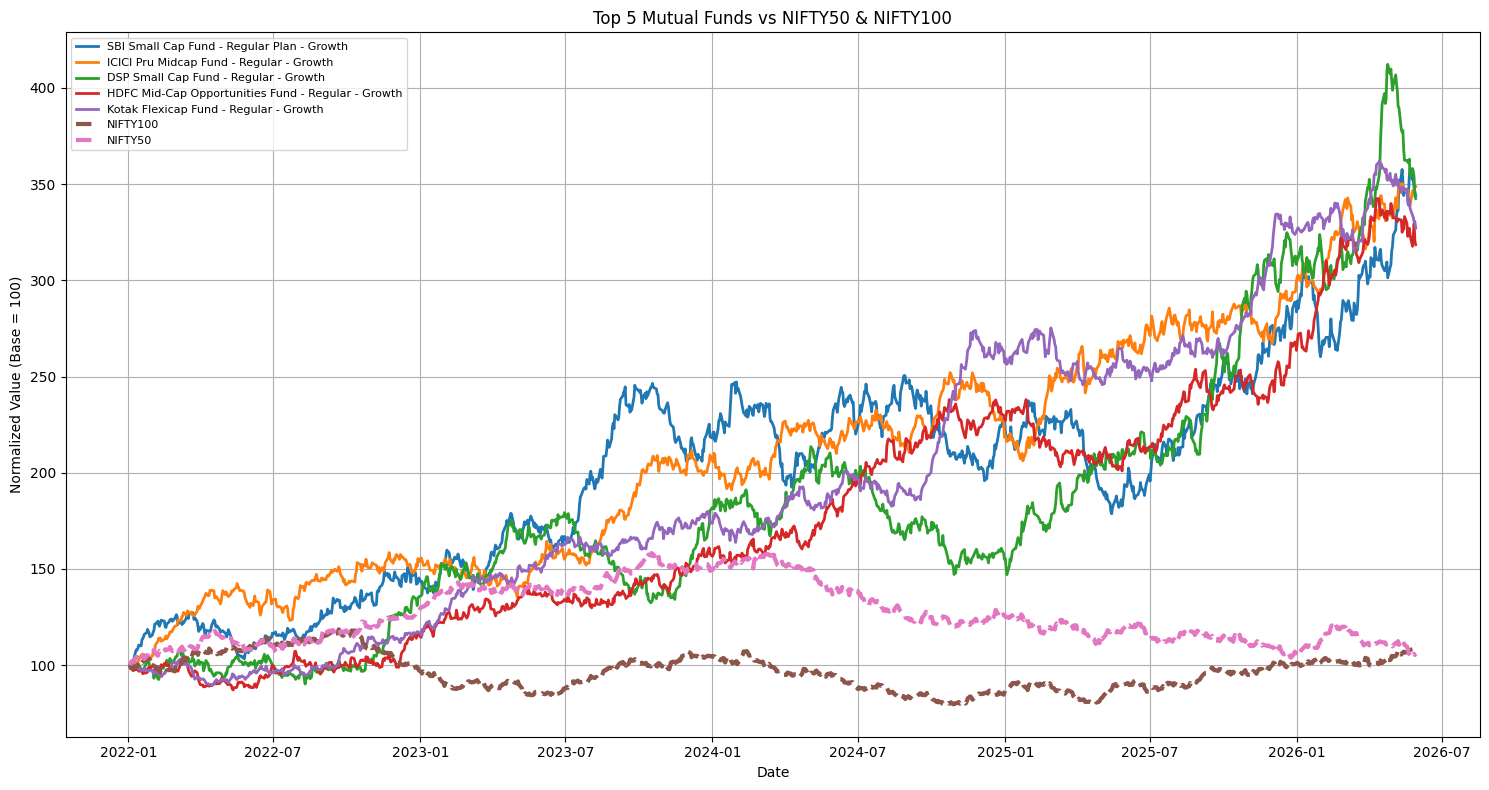

In [182]:
plt.figure(figsize=(15,8))

# Plot Top 5 Funds
for code in top5_codes:

    temp = top5_nav[top5_nav["amfi_code"] == code]

    plt.plot(
        temp["date"],
        temp["Normalized_NAV"],
        linewidth=2,
        label=temp["scheme_name"].iloc[0]
    )

# Plot Benchmarks
for index in benchmark["index_name"].unique():

    temp = benchmark[
        benchmark["index_name"] == index
    ]

    plt.plot(
        temp["date"],
        temp["Normalized_Index"],
        linestyle="--",
        linewidth=3,
        label=index
    )

plt.title("Top 5 Mutual Funds vs NIFTY50 & NIFTY100")

plt.xlabel("Date")

plt.ylabel("Normalized Value (Base = 100)")

plt.grid(True)

plt.legend(fontsize=8)

plt.tight_layout()

os.makedirs("../dashboard", exist_ok=True)

plt.savefig(
    "../dashboard/benchmark_comparison.png",
    dpi=300
)

plt.show()

In [183]:
tracking_results = []

benchmark100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

benchmark100 = benchmark100.sort_values("date")

benchmark100["benchmark_return"] = benchmark100["close_value"].pct_change()

for code in top5_codes:

    temp = nav_df[
        nav_df["amfi_code"] == code
    ].copy()

    temp = temp.sort_values("date")

    temp["fund_return"] = temp["nav"].pct_change()

    merged = pd.merge(
        temp,
        benchmark100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    tracking_error = (
        (merged["fund_return"] - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_results.append([
        code,
        temp["scheme_name"].iloc[0],
        tracking_error
    ])

tracking_error_df = pd.DataFrame(
    tracking_results,
    columns=[
        "amfi_code",
        "scheme_name",
        "Tracking_Error"
    ]
)

tracking_error_df

,amfi_code,scheme_name,Tracking_Error
0,119598,SBI Small Cap Fund - Regular Plan - Growth,0.283881
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.231968
2,149324,DSP Small Cap Fund - Regular - Growth,0.279170
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228699
4,120843,Kotak Flexicap Fund - Regular - Growth,0.206425


In [184]:
os.makedirs("../reports", exist_ok=True)

tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

tracking_error_df

,amfi_code,scheme_name,Tracking_Error
0,119598,SBI Small Cap Fund - Regular Plan - Growth,0.283881
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.231968
2,149324,DSP Small Cap Fund - Regular - Growth,0.279170
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228699
4,120843,Kotak Flexicap Fund - Regular - Growth,0.206425


In [185]:
print("Benchmark Comparison Image:",
      os.path.exists("../dashboard/benchmark_comparison.png"))

print("Tracking Error CSV:",
      os.path.exists("../reports/tracking_error.csv"))

Benchmark Comparison Image: True
Tracking Error CSV: True
